In [30]:
import numpy as np
import pandas as pd
import optuna
import warnings
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA  # <--- IMPORTIAMO LA PCA
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor

# Modelli
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor

# Configurazione
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [31]:
print("1. Caricamento e Pulizia Dati...")

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")
df = pd.concat([X, y], axis=1)

# Rimuoviamo il cap a 5.0
df = df[df['MedHouseVal'] < 5.0]

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    indices_to_drop = []
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df_clean[(df_clean[col] < Q1 - 2.0*IQR) | (df_clean[col] > Q3 + 2.0*IQR)].index
        indices_to_drop.extend(outliers)
    return df_clean.drop(list(set(indices_to_drop)))

cols_clean = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']
df = remove_outliers_iqr(df, cols_clean)
print(f"   -> Dataset pulito: {df.shape}")

1. Caricamento e Pulizia Dati...
   -> Dataset pulito: (18223, 9)


In [32]:
# ---------------------------------------------------------
# 2. FEATURE ENGINEERING MASSIVA
# ---------------------------------------------------------
print("2. Generazione Feature 'Combo'...")

def generate_comprehensive_features(df_input, cols_to_combine):
    df_eng = df_input.copy()
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    # Trucco Rotazione Coordinate
    df_eng['Rot_45_LatLon'] = df_eng['Latitude'] + df_eng['Longitude']
    df_eng['Rot_N45_LatLon'] = df_eng['Latitude'] - df_eng['Longitude']

    # A. LOGARITMI
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. MOLTIPLICAZIONI
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]

    # C. DIVISIONI
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)

    return df_eng

# Geo Features
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)
df['Dist_SF'] = np.sqrt((df['Latitude'] - sf_coords[0])**2 + (df['Longitude'] - sf_coords[1])**2)
df['Dist_LA'] = np.sqrt((df['Latitude'] - la_coords[0])**2 + (df['Longitude'] - la_coords[1])**2)

coords = df[['Latitude', 'Longitude']]
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df['Geo_Cluster'] = kmeans.fit_predict(StandardScaler().fit_transform(coords))

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_comprehensive_features(X, cols_for_math)
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)
print(f"   -> Totale Feature Generate: {X_full.shape[1]}")

2. Generazione Feature 'Combo'...
   -> Totale Feature Generate: 105


3. Applicazione PCA e Scree Plot...


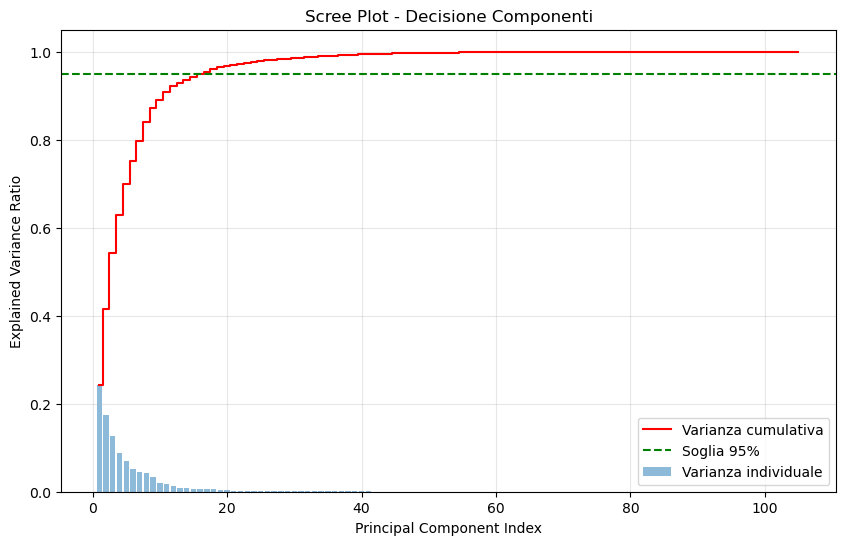

   -> PCA Completata. Feature ridotte da 105 a 17
   -> Varianza totale conservata: 95.48%


In [33]:
# ---------------------------------------------------------
# 3. DIMENSIONALITY REDUCTION (PCA + SCREE PLOT)
# ---------------------------------------------------------
print("3. Applicazione PCA e Scree Plot...")

# 3.1 Standardizzazione (OBBLIGATORIA per PCA)
# Usiamo StandardScaler perché la PCA massimizza la varianza.
# (RobustScaler va bene per gli outlier, ma standardizzare a var=1 è standard per PCA)
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_full)

# 3.2 Fit PCA Completa per analisi
pca_full = PCA()
pca_full.fit(X_scaled_pca)

# 3.3 Scree Plot
exp_var_pca = pca_full.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, label='Varianza individuale')
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid', label='Varianza cumulativa', color='red')
plt.axhline(y=0.95, color='green', linestyle='--', label='Soglia 95%')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot - Decisione Componenti')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# 3.4 Selezione Automatica Componenti (95% Varianza)
# Invece di n_components=int, passiamo un float tra 0 e 1.
# Scikit-learn sceglierà automaticamente il numero minimo di componenti per coprire quella varianza.
pca_final = PCA(n_components=0.95)
X_selected = pca_final.fit_transform(X_scaled_pca)

n_components_kept = X_selected.shape[1]
print(f"   -> PCA Completata. Feature ridotte da {X_full.shape[1]} a {n_components_kept}")
print(f"   -> Varianza totale conservata: {np.sum(pca_final.explained_variance_ratio_):.2%}")

# Split Principale (Train / Test)
# Nota: X_selected ora è un numpy array, perdiamo i nomi delle colonne ma va bene per i modelli
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [ ]:
# ---------------------------------------------------------
# 4. OPTUNA REALE CON EARLY STOPPING CORRETTO
# ---------------------------------------------------------
print("\n4. Tuning Iperparametri con Optuna e Early Stopping...")

# Creiamo un set di validazione SOLO per Optuna per monitorare l'early stopping
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

N_TRIALS = 50  # Numero di trial (aumentare per risultati migliori)

# --- A. XGBoost Optimization ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.6),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'alpha': trial.suggest_float('alpha', 1e-9, 15.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-9, 15.0, log=True),
        'n_jobs': -1, 'random_state': 42
    }
    
    model = XGBRegressor(**params)
    
    # Verbose=False sopprime i log, eval_set serve per l'early stopping
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        verbose=False
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. CatBoost Optimization ---
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    
    model = CatBoostRegressor(**params)
    
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        early_stopping_rounds=100
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

# --- C. LightGBM Optimization (New Callback API) ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'num_leaves': trial.suggest_int('num_leaves', 25, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'n_jobs': -1, 'verbose': -1, 'random_state': 42
    }
    
    model = LGBMRegressor(**params)
    
    # NEW API: Usiamo callbacks invece di early_stopping_rounds in .fit()
    callbacks = [
        early_stopping(stopping_rounds=100, verbose=False),
        log_evaluation(period=0) # Zittisce l'output
    ]
    
    try:
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    except Exception as e:
        # Fallback CPU se GPU crasha o non presente
        params['device'] = 'cpu'
        model = LGBMRegressor(**params)
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )

    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# Recupero i migliori parametri
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'n_estimators': 2000, 'tree_method': 'hist', 'device': 'cpu', 'n_jobs': -1, 'random_state': 42})
# Rimuoviamo early_stopping_rounds dai params per il fit finale (opzionale, ma pulito)
if 'early_stopping_rounds' in best_xgb_params: del best_xgb_params['early_stopping_rounds']

best_cat_params = study_cat.best_params
best_cat_params.update({'iterations': 2000, 'task_type': 'CPU', 'devices': '0', 'verbose': 0, 'random_state': 42})

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'n_estimators': 2000, 'device': 'cpu', 'n_jobs': -1, 'verbosity': -1, 'random_state': 42})

print("\n--- Optuna Completato. Parametri migliori trovati. ---")


'\n# ---------------------------------------------------------\n# 4. OPTUNA REALE CON EARLY STOPPING CORRETTO\n# ---------------------------------------------------------\nprint("\n4. Tuning Iperparametri con Optuna e Early Stopping...")\n\n# Creiamo un set di validazione SOLO per Optuna per monitorare l\'early stopping\nX_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(\n    X_train, y_train, test_size=0.2, random_state=42\n)\n\nN_TRIALS = 50  # Numero di trial (aumentare per risultati migliori)\n\n# --- A. XGBoost Optimization ---\ndef objective_xgb(trial):\n    params = {\n        \'n_estimators\': trial.suggest_int(\'n_estimators\', 600, 1200),\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.001, 0.6),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 2, 20),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.6, 0.95),\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.6, 0.95),\n        \'alpha\': trial.

In [ ]:
'''
# ---------------------------------------------------------
# 4. OPTUNA REALE CON EARLY STOPPING
# ---------------------------------------------------------
print("\n4. Tuning Iperparametri con Optuna...")

X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

N_TRIALS = 50 # Ridotto leggermente per brevità demo

# --- A. XGBoost Optimization ---
def objective_xgb(trial):
    params = {
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'tree_method': 'hist',
        'n_jobs': -1,
        'random_state': 42,
        'early_stopping_rounds': 100
    }
    model = XGBRegressor(**params)
    model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], verbose=False)
    return np.sqrt(mean_squared_error(y_opt_val, model.predict(X_opt_val)))

print("   -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. CatBoost Optimization ---
def objective_cat(trial):
    params = {
        'iterations': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('depth', 6, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0,
        'allow_writing_files': False,
        'random_state': 42,
        'eval_metric': 'RMSE'
    }
    model = CatBoostRegressor(**params)
    model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], early_stopping_rounds=100)
    return np.sqrt(mean_squared_error(y_opt_val, model.predict(X_opt_val)))

print("   -> Optimizing CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

# --- C. LightGBM Optimization ---
def objective_lgbm(trial):
    params = {
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 30, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10),
        'n_jobs': -1,
        'verbosity': -1,
        'random_state': 42,
        'metric': 'rmse'
    }
    model = LGBMRegressor(**params)
    callbacks = [early_stopping(stopping_rounds=100, verbose=False), log_evaluation(period=0)]
    try:
        model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], eval_metric='rmse', callbacks=callbacks)
    except:
        params['device'] = 'cpu'
        model = LGBMRegressor(**params)
        model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], eval_metric='rmse', callbacks=callbacks)
    return np.sqrt(mean_squared_error(y_opt_val, model.predict(X_opt_val)))

print("   -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# Recupero best params
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'n_estimators': 2000, 'tree_method': 'hist', 'n_jobs': -1, 'random_state': 42})
if 'early_stopping_rounds' in best_xgb_params: del best_xgb_params['early_stopping_rounds']

best_cat_params = study_cat.best_params
best_cat_params.update({'iterations': 2000, 'devices': '0', 'verbose': 0, 'random_state': 42})

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'n_estimators': 2000, 'n_jobs': -1, 'verbosity': -1, 'random_state': 42})
'''


4. Tuning Iperparametri con Optuna...
   -> Optimizing XGBoost...
   -> Optimizing CatBoost...
   -> Optimizing LightGBM...


In [36]:
# ---------------------------------------------------------
# 5. SMART SOFT MODEL SELECTOR (MoE)
# ---------------------------------------------------------
print("\n5. Costruzione Smart Soft Selector (MoE)...")


class SmartSoftModelSelector(BaseEstimator, RegressorMixin):
    def __init__(self, estimators, selector_model=None):
        self.estimators = estimators
        self.selector_model = selector_model if selector_model else XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            tree_method='hist', n_jobs=-1, random_state=42
        )
        self.model_names = [name for name, _ in estimators]
        
    def fit(self, X, y):
        self.fitted_estimators_ = []
        for name, model in self.estimators:
            model.fit(X, y)
            self.fitted_estimators_.append(model)
            
        # Generazione OOF per il Selettore
        errors = pd.DataFrame()
        for name, model in self.estimators:
            oof_preds = cross_val_predict(model, X, y, cv=5, n_jobs=1)
            errors[name] = np.abs(y - oof_preds)
            
        y_best_model_idx = errors.idxmin(axis=1).apply(lambda x: self.model_names.index(x))
        self.selector_model.fit(X, y_best_model_idx)
        return self

    def predict(self, X):
        base_preds = np.column_stack([model.predict(X) for model in self.fitted_estimators_])
        weights = self.selector_model.predict_proba(X)
        final_pred = np.sum(base_preds * weights, axis=1)
        return final_pred

estimators_list = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params)) 
]

moe_model = SmartSoftModelSelector(estimators=estimators_list)
moe_model.fit(X_train, y_train)


5. Costruzione Smart Soft Selector (MoE)...


SmartSoftModelSelector(estimators=[('xgb',
                                    XGBRegressor(base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=0.87327788080271,
                                                 device=None,
                                                 early_stopping_rounds=None,
                                                 enable_categorical=False,
                                                 eval_metric=None,
                                                 feature_types=None,
                                                 feature_weights=None,
                                                 gamma=None, grow_policy=None,
                                                 importance_type=None,
                                                 in...
                                                    feature_weights=None,
                                                    gamma=None,
                                                    grow_policy=None,
                                                    importance_type=None,
                                                    interaction_constraints=None,
                                                    learning_rate=0.05,
                                                    max_bin=None,
                                                    max_cat_threshold=None,
                                                    max_cat_to_onehot=None,
                                                    max_delta_step=None,
                                                    max_depth=6,
                                                    max_leaves=None,
                                                    min_child_weight=None,
                                                    missing=nan,
                                                    monotone_constraints=None,
                                                    multi_strategy=None,
                                                    n_estimators=200, n_jobs=-1,
                                                    num_parallel_tree=None, ...))

In [37]:
# ---------------------------------------------------------
# 6. RESIDUAL LEARNING
# ---------------------------------------------------------
print("\n6. Training Correttore dei Residui...")

class ResidualCorrectedMoE(BaseEstimator, RegressorMixin):
    def __init__(self, base_moe_model, corrector_model=None):
        self.base_moe_model = base_moe_model
        self.corrector_model = corrector_model if corrector_model else CatBoostRegressor(
            iterations=500, depth=6, learning_rate=0.03, l2_leaf_reg=5, 
            task_type='CPU', devices='0', verbose=0, allow_writing_files=False, random_state=42
        )
        
    def fit(self, X, y):
        # Calcolo residui OOF
        oof_preds = cross_val_predict(self.base_moe_model, X, y, cv=5, n_jobs=1)
        residuals = y - oof_preds
        self.corrector_model.fit(X, residuals)
        return self

    def predict(self, X):
        base_pred = self.base_moe_model.predict(X)
        correction = self.corrector_model.predict(X)
        return base_pred + correction

final_system = ResidualCorrectedMoE(base_moe_model=moe_model)
final_system.fit(X_train, y_train)

# Valutazione
y_pred_corrected = final_system.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_corrected))
final_r2 = r2_score(y_test, y_pred_corrected)

print(f"\n==========================================")
print(f" RISULTATI FINALI (con PCA)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f"==========================================")


6. Training Correttore dei Residui...

 RISULTATI FINALI (con PCA)
 RMSE: 0.46521
 R^2 : 0.76976


In [38]:
# ---------------------------------------------------------
# 5. STACKING FINALE (Ensemble)
# ---------------------------------------------------------
print("\n5. Addestramento Stacking Ensemble Finale (su set completo)...")

# Recuperiamo i migliori parametri 
best_xgb_params = study_xgb.best_params
# Assicuriamoci che non ci siano parametri di fit residui
best_xgb_params.update({
    'tree_method': 'hist', 'n_jobs': -1, 
    'random_state': 42, 'early_stopping_rounds': None # Disabilita early stopping per il fit finale
})

best_cat_params = study_cat.best_params
best_cat_params.update({
    'verbose': 0, 
    'allow_writing_files': False, 'random_state': 42
})

best_lgbm_params = study_lgbm.best_params
if study_lgbm.best_params.get('device') == 'cpu':
    best_lgbm_params.update({'n_jobs': -1, 'verbosity': -1, 'random_state': 42})
else:
    best_lgbm_params.update({'n_jobs': -1, 'verbosity': -1, 'random_state': 42})

estimators = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params))
]

# Stacking Regressor non supporta nativamente early stopping nei sotto-modelli
# durante il cross-validation interno in modo semplice, quindi usiamo n_estimators ottimizzati
# (Nota: idealmente dovresti settare n_estimators al valore ottimo trovato durante Optuna, 
# ma qui li lasciamo alti o default per lo stacking standard)

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=1 
)

stacking.fit(X_train, y_train)


5. Addestramento Stacking Ensemble Finale (su set completo)...


StackingRegressor(cv=5,
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.87327788080271,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            in...
                               <catboost.core.CatBoostRegressor object at 0x32a6b1e20>),
                              ('lgbm',
                               LGBMRegressor(bagging_fraction=0.792304662470931,
                                             bagging_freq=6,
                                             feature_fraction=0.7483917723884155,
                                             learning_rate=0.0072107218122417155,
                                             min_child_samples=75, n_jobs=-1,
                                             num_leaves=176, random_state=42,
                                             reg_alpha=0.1031564491658201,
                                             reg_lambda=4.629481227810667,
                                             verbosity=-1))],
                  final_estimator=RidgeCV(), n_jobs=1)

In [39]:
# ---------------------------------------------------------
# 6. VALUTAZIONE FINALE
# ---------------------------------------------------------
y_pred = stacking.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f"\n==========================================")
print(f" RISULTATI FINALI (PCA)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f"==========================================")


 RISULTATI FINALI (PCA)
 RMSE: 0.47364
 R^2 : 0.76135
